In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob 
from qumas.census import LensedQsoCensus
from qumas.LensmodelWrapper.automatic_modeling_time_delay import automatic_modeling
from qumas.LensmodelWrapper.utils import pandas_to_model,read_pickle
from qumas.LensmodelWrapper.lensmodel_result_handler import Result_Handler





In [2]:
%load_ext autoreload
%autoreload 2

In [12]:

LQC=LensedQsoCensus()
current_directory=os.getcwd() 
path_for_models = "/home/felipe/work/MicrolensingProjects/Analysis/"
dir_models="models"
use_real_error_flux=False #xd
modo_fast=True #que se supone q hace eso?
S = []
# for system_name in LQC.unique_systems_count("name"):#,"Q1355-2257","QJ0158"]:
#     print(f'{system_name}')
#     system = pandas_to_model(LQC.hierarchical_selection(system_name))
#     break
lens1 = LQC.look_for_a_system("SDSS1004+4112")
system = pandas_to_model(lens1)
#system = pandas_to_model(LQC.hierarchical_selection("GRAL1651-0417"))
System_result,modeling_path = automatic_modeling(system,max_separation=0.01,path_for_models=path_for_models,dir_models=dir_models,model_All=False,do_mcmc=False,use_informed_flux=False,use_real_error_flux=False,max_lap=0)

len of the subpandas [5, 7]
available_lens_models: ['SIS+shear' 'SIS+shear-2G' 'SIE' 'SIE-2G' 'SIE+shear' 'SIE+shear-2G']
lap 0 Modeled SDSS1004+4112 using SIS+shear center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003
lap 0 Modeled SDSS1004+4112 using SIS+shear-2G center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003
lap 0 Modeled SDSS1004+4112 using SIE center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003
lap 0 Modeled SDSS1004+4112 using SIE-2G center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003
lap 0 Modeled SDSS1004+4112 using SIE+shear center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003
lap 0 Modeling SDSS1004+4112 using SIE+shear-2G center_mass_error 0.003 relative_flux_error 0.2 astrometry_error 0.003


IndexError: list index out of range

In [6]:
System_result.get_model("model_1").keys()

dict_keys(['best_model_file', 'model_setup_file', 'modeling_file', 'final_step_file', 'step_1', 'step_2', 'final_step', 'kappa_gamma', 'critical_caustic', 'grid', 'RE', 'model_setup'])

In [7]:
System_result.get_model("model_1")["modeling_file"]

['#mass_distribution = SIS+shear \n',
 'data /home/felipe/work/MicrolensingProjects/Analysis/models/SDSS1004+4112/SDSS1004+4112.dat #file whit data \n',
 'set omitcore =  0.05 #radius to avoid errors \n',
 'set omega =  0.3 \n',
 'set lambda =  0.7 \n',
 'set hval = 0.7 \n',
 'set hvale = 1000 #Uncertainty in H_0 in units of 100 km/s/Mpc \n',
 'set chimode = 1 #source plane \n',
 'set zlens = 0.68 #lens_redshift \n',
 'set zsrc = 1.734 #source_redshift \n',
 "set checkparity = 0 # don't worry about parities \n",
 "#set gridflag =  0 # don't need the tiling \n",
 'set restart =  2 \n',
 '#Start modeling  \n',
 'startup  2 1 #number of lens \n',
 'alpha 7.36 0 0 0.0 0.0 0.003 10.0 0 0 1\n',
 'alpha 3.68 -3.393 -5.408 0.0 0.0 0 0.0 0 0 1\n',
 '1 0 0 0 0 1 1 0 0 0\n',
 '1 0 0 0 0 0 0 0 0 0\n',
 'varyone 1 7 -90.0 90.0 19 /home/felipe/work/MicrolensingProjects/Analysis/models/SDSS1004+4112/step_1\n',
 'setlens /home/felipe/work/MicrolensingProjects/Analysis/models/SDSS1004+4112/step_1.start

In [24]:
from pathlib import Path
out_path = Path("/home/felipe/work/MicrolensingProjects/Analysis/models/SDSS1004+4112/SDSS1004+4112.dat")
out_path.parent.mkdir(parents=True, exist_ok=True)
lines = System_result.get_model("model_1")["model_setup_file"]
with out_path.open("w", encoding="utf-8") as f:
    f.writelines(lines)

In [23]:
System_result.get_model("model_1").keys()

dict_keys(['best_model_file', 'model_setup_file', 'modeling_file', 'final_step_file', 'step_1', 'step_2', 'final_step', 'kappa_gamma', 'critical_caustic', 'grid', 'RE', 'model_setup'])

In [39]:
System_result.get_model("model_1")["best_model_file"]

['2 1\n',
 '   alpha 2.529803e+00 -4.870584e-02 3.398624e-01 0.0 0.0 1.445375e-01 -6.412064e+01 0.0 0.0 1.000000e+00\n',
 '   alpha 5.828320e+00 2.204423e-01 -6.414611e+00 0.0 0.0 0.0 0.0 0.0 0.0 1.000000e+00\n',
 ' 1 1 1 0 0 1 1 0 0 0\n',
 ' 1 1 1 0 0 0 0 0 0 0\n']

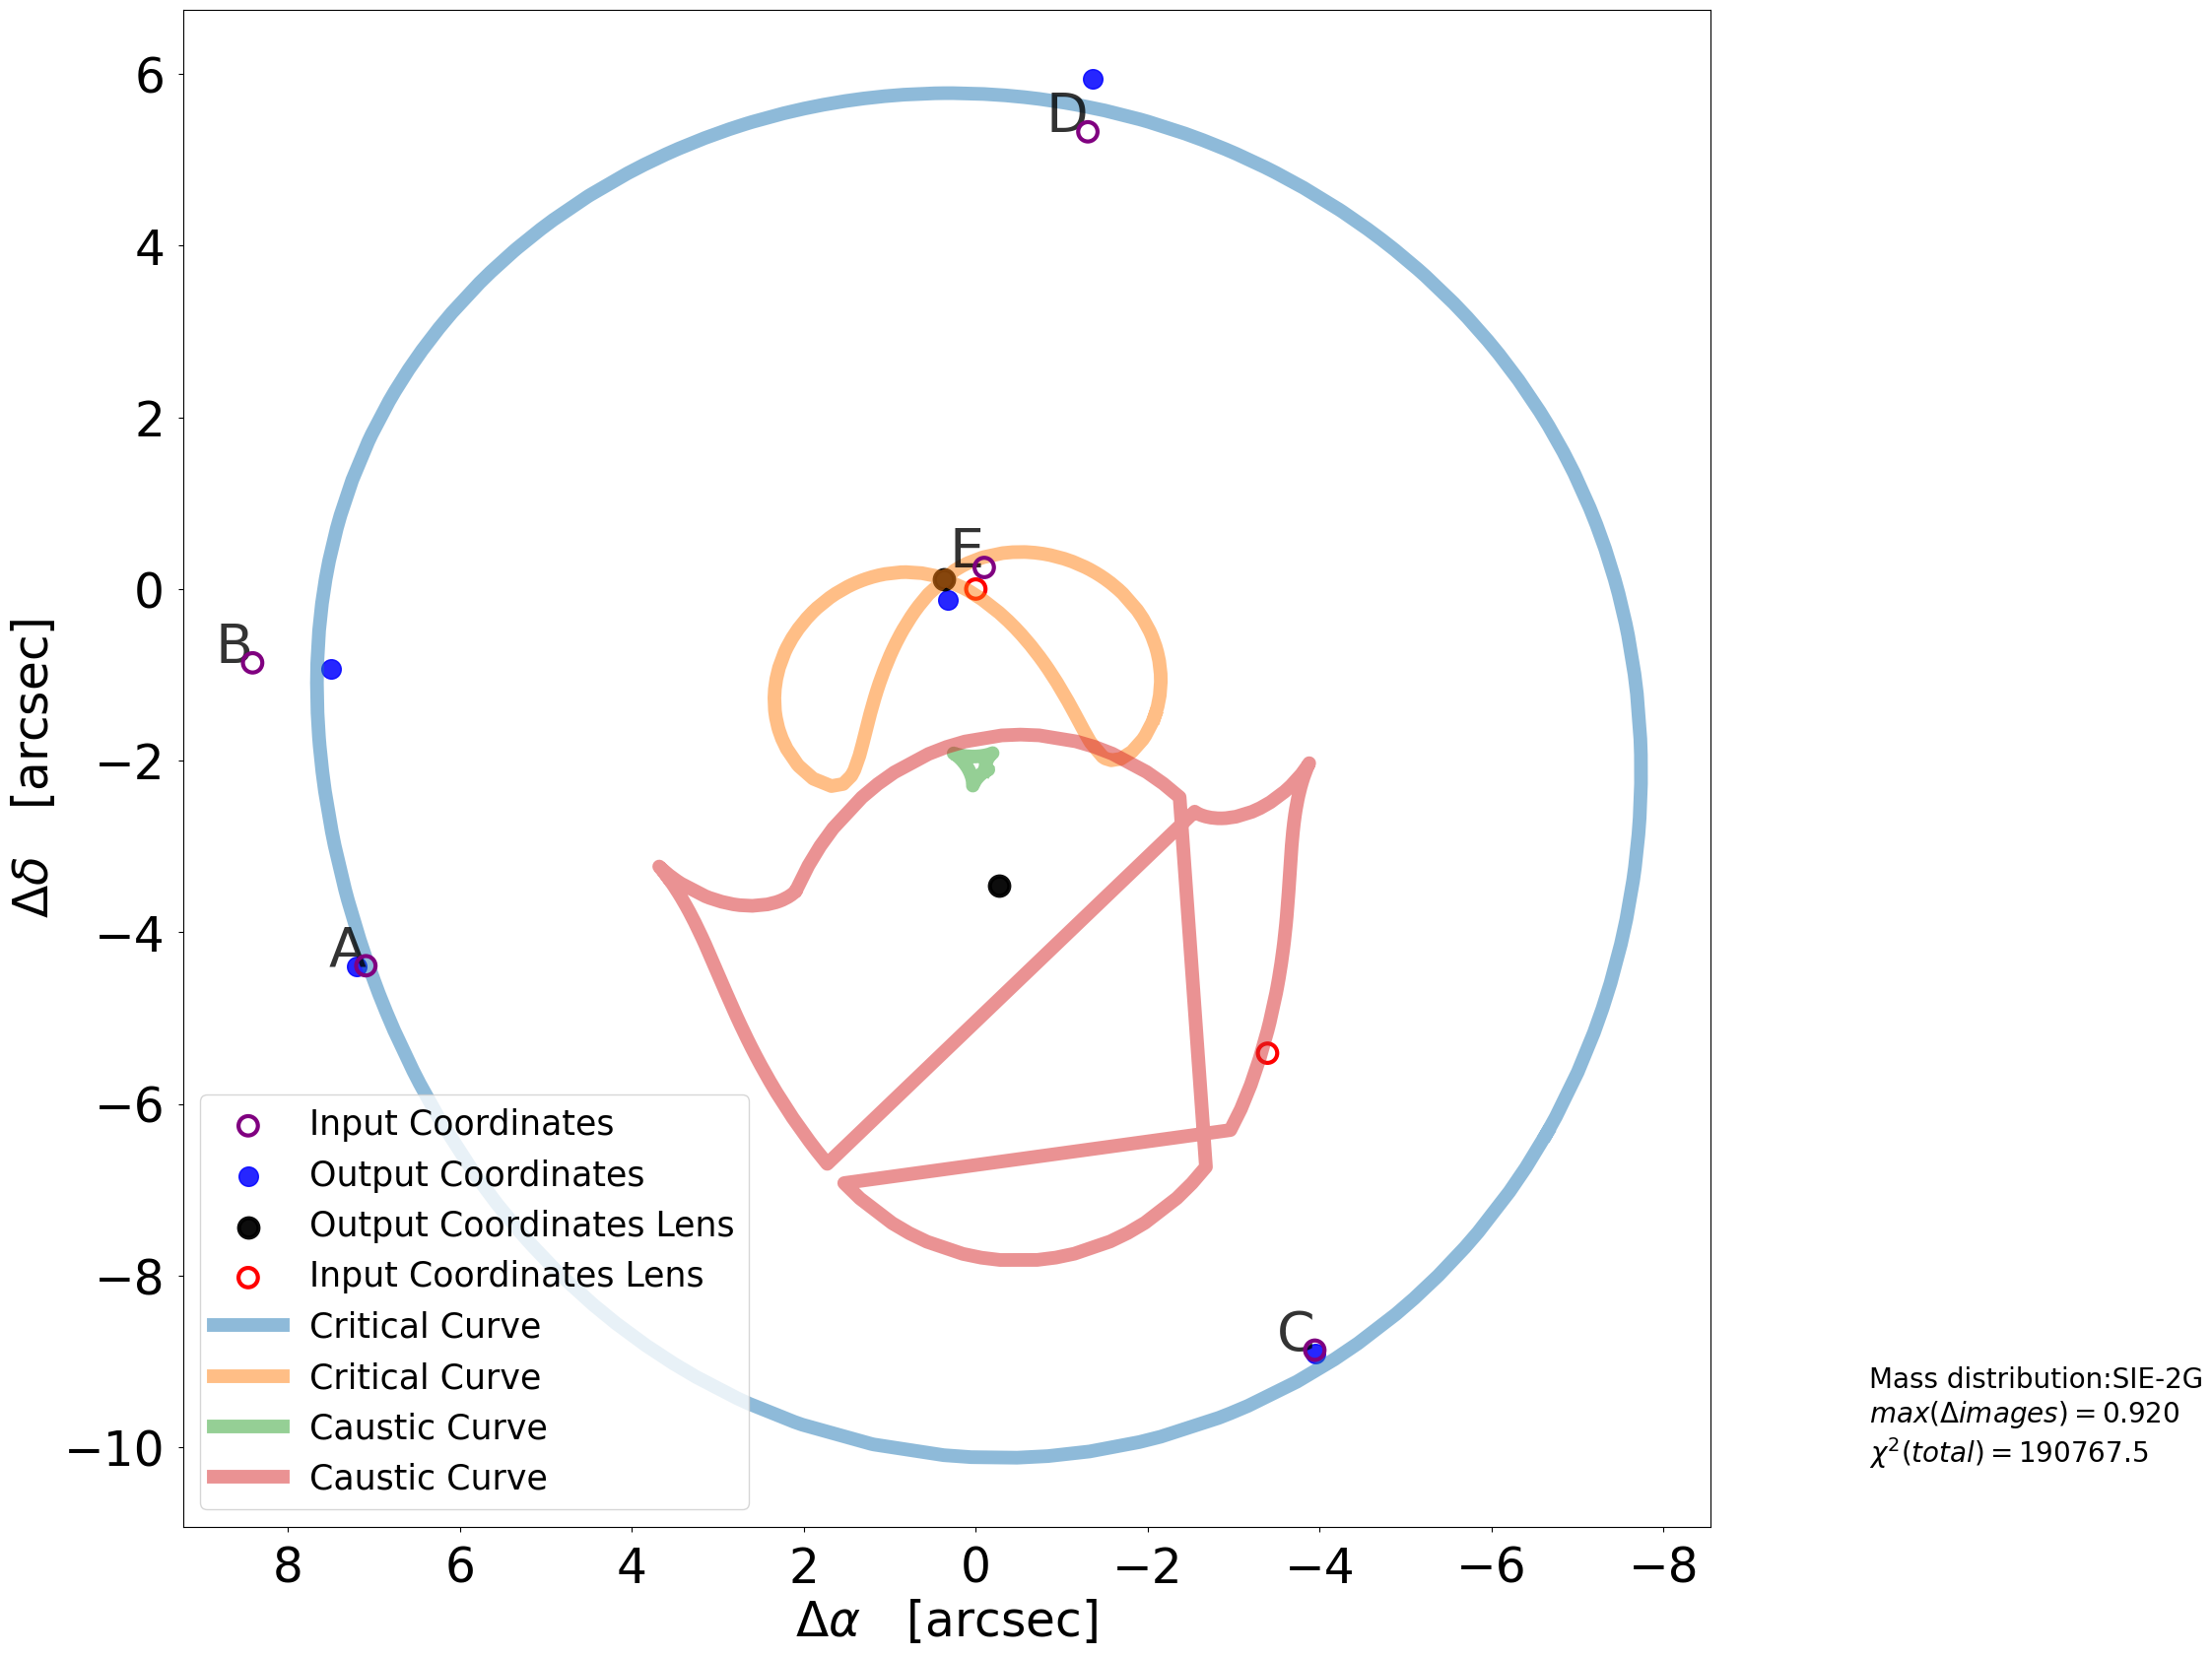

In [10]:
System_result.make_plot(model="model_3",add_critical=True,add_info=True)